In [1]:
#  1. IMPORTACIÓN DE LIBRERÍAS

import pandas as pd
import numpy as np

import nltk # Biblioteca especializada en procesamiento de lenguaje natural.
import re # re:  Permite trabajar con expresiones regulares. # Lo utilizaremos para eliminar HTML, números, etc.
import string  # string: Contiene caracteres y herramientas relacionadas con texto. o utilizaremos para eliminar
#signos de puntuación.


# COMPONENTES DE NLTK
from nltk.corpus import stopwords # Contiene listas de palabras frecuentes que podemos eliminar.
from nltk.tokenize import word_tokenize # Divide una oración o texto en tokens.
from nltk.stem import SnowballStemmer # Realiza stemming, reduciendo palabras a una raíz aproximada.
from nltk.stem import WordNetLemmatizer # Realiza lematización.


# COMPONENTES DE SCIKIT-LEARN
from sklearn.model_selection import train_test_split # Divide los datos en entrenamiento y prueba.

from sklearn.feature_extraction.text import TfidfVectorizer # Convierte documentos de texto en representación numérica TF-IDF.

from sklearn.linear_model import LogisticRegression # Algoritmo de Machine Learning para clasificación.

# Métricas para evaluar el modelo.
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# VISUALIZACIÓN
import matplotlib.pyplot as plt # Permite crear gráficos. # Facilita la creación de gráficos estadísticos.
import seaborn as sns

In [2]:
nltk.download("punkt") # Recurso necesario para tokenización.
nltk.download("stopwords") # Recurso que contiene las stopwords.
nltk.download("wordnet") # Recurso necesario para WordNet.
nltk.download("omw-1.4") # Recurso adicional utilizado por WordNet.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
df = pd.read_csv("sample_data/IMDB Dataset.csv")
# Mostramos las primeras filas.
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# VERIFICAR COLUMNAS
print("Columnas del dataset:")
print(df.columns)

Columnas del dataset:
Index(['review', 'sentiment'], dtype='object')


In [5]:
# DIMENSIONES
print("Dimensiones:")
print(df.shape)

Dimensiones:
(50000, 2)


In [6]:
# INFORMACIÓN GENERAL
print("\nInformación:")
print(df.info())



Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


In [7]:
# TVALORES NULOS
print("\nValores nulos:")
print(df.isnull().sum())


Valores nulos:
review       0
sentiment    0
dtype: int64


In [8]:
# DISTRIBUCIÓN DE CLASES
print(df["sentiment"].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [9]:
# TRADUCIR LAS ETIQUETAS
#Crearemos una columna adicional: sentimiento (traducido)

df["sentimiento"] = df["sentiment"].map({
    "positive": "positivo",
    "negative": "negativo"
})

In [10]:
df.head()

,review,sentiment,sentimiento
0,One of the other reviewers has mentioned that ...,positive,positivo
1,A wonderful little production. <br /><br />The...,positive,positivo
2,I thought this was a wonderful way to spend ti...,positive,positivo
3,Basically there's a family where a little boy ...,negative,negativo
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,positivo


In [11]:
# CREAR ETIQUETA NUMÉRICA
# para Machine Learning recomiendo algo diferente
#Para el modelo es más cómodo tener:
# negative → 0
# positive → 1
df["etiqueta"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

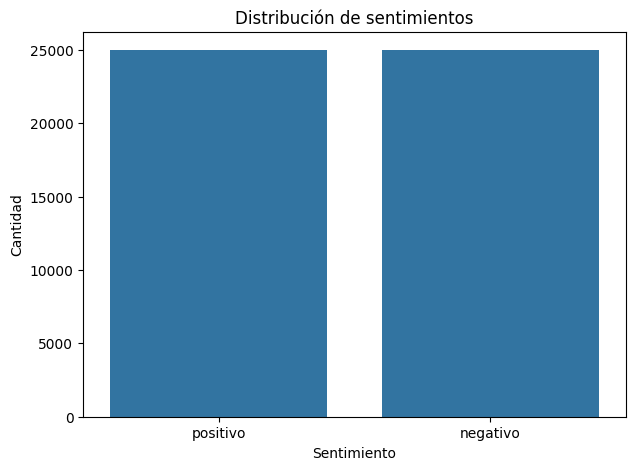

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="sentimiento"
)

plt.title("Distribución de sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad")

plt.show()

#esta balanceado el dataset?  Sí, aproximadamente el 50 % corresponde a reseñas positivas y el 50 % a reseñas negativas.

In [13]:
#  PREPROCESAMIENTO

In [14]:
def limpiar_texto(texto):
    # Convertir a minúsculas
    texto = texto.lower()

    # Eliminar etiquetas HTML

    texto = re.sub(
        r"<.*?>",
        " ",
        texto
    )

    # Eliminar números

    texto = re.sub(
        r"\d+",
        " ",
        texto
    )


    # Eliminar signos de puntuación

    texto = texto.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )


    # Eliminar espacios repetidos

    texto = re.sub(
        r"\s+",
        " ",
        texto
    ).strip()




    return texto

In [15]:
texto_prueba = """
A wonderful little production. <br /><br />The...
"""

print("Original:")
print(texto_prueba)

print("\nProcesado:")
print(limpiar_texto(texto_prueba))

Original:

A wonderful little production. <br /><br />The...


Procesado:
a wonderful little production the


In [16]:

df["texto_limpio"] = df["review"].apply(
    limpiar_texto
)

In [17]:
df.texto_limpio


,texto_limpio
0,one of the other reviewers has mentioned that ...
1,a wonderful little production the filming tech...
2,i thought this was a wonderful way to spend ti...
3,basically theres a family where a little boy j...
4,petter matteis love in the time of money is a ...
...,...
49995,i thought this movie did a down right good job...
49996,bad plot bad dialogue bad acting idiotic direc...
49997,i am a catholic taught in parochial elementary...
49998,im going to have to disagree with the previous...


In [18]:
#  TOKENIZACIÓN


def tokenizar(texto):

    return word_tokenize(texto)

In [19]:
import nltk

In [20]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
texto = "this movie is fantastic"

tokens = tokenizar(texto)

print(tokens)

['this', 'movie', 'is', 'fantastic']


In [22]:

df["tokens"] = df["texto_limpio"].apply(
    tokenizar
)

In [23]:
df.head(10)

,review,sentiment,sentimiento,etiqueta,texto_limpio,tokens
0,One of the other reviewers has mentioned that ...,positive,positivo,1,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,A wonderful little production. <br /><br />The...,positive,positivo,1,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin..."
2,I thought this was a wonderful way to spend ti...,positive,positivo,1,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,..."
3,Basically there's a family where a little boy ...,negative,negativo,0,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,positivo,1,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon..."
5,"Probably my all-time favorite movie, a story o...",positive,positivo,1,probably my alltime favorite movie a story of ...,"[probably, my, alltime, favorite, movie, a, st..."
6,I sure would like to see a resurrection of a u...,positive,positivo,1,i sure would like to see a resurrection of a u...,"[i, sure, would, like, to, see, a, resurrectio..."
7,"This show was an amazing, fresh & innovative i...",negative,negativo,0,this show was an amazing fresh innovative idea...,"[this, show, was, an, amazing, fresh, innovati..."
8,Encouraged by the positive comments about this...,negative,negativo,0,encouraged by the positive comments about this...,"[encouraged, by, the, positive, comments, abou..."
9,If you like original gut wrenching laughter yo...,positive,positivo,1,if you like original gut wrenching laughter yo...,"[if, you, like, original, gut, wrenching, laug..."


In [24]:
#  STOPWORDS: ahora eliminares palabras frecuentes: the, is ,a , an, of, to ,and
stop_words = set(
    stopwords.words("english")
)

print("Cantidad de stopwords:")
print(len(stop_words))

Cantidad de stopwords:
198


In [25]:
def eliminar_stopwords(tokens):

    return [
        palabra
        for palabra in tokens
        if palabra not in stop_words
    ]

In [26]:
tokens_prueba = [
    "this",
    "movie",
    "is",
    "really",
    "good"
]

print(
    eliminar_stopwords(tokens_prueba)
)

['movie', 'really', 'good']


In [27]:
df["tokens_sin_stopwords"] = df[
    "tokens"
].apply(
    eliminar_stopwords
)

In [28]:
df.head(3)

,review,sentiment,sentimiento,etiqueta,texto_limpio,tokens,tokens_sin_stopwords
0,One of the other reviewers has mentioned that ...,positive,positivo,1,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, oz, epis..."
1,A wonderful little production. <br /><br />The...,positive,positivo,1,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin...","[wonderful, little, production, filming, techn..."
2,I thought this was a wonderful way to spend ti...,positive,positivo,1,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su..."


In [29]:
# STEMMING

stemmer = SnowballStemmer(
    "english"
)

In [30]:
#creamos la funcion
def aplicar_stemming(tokens):

    return [
        stemmer.stem(palabra)
        for palabra in tokens
    ]

In [31]:
# probamos
tokens_prueba = [
    "playing",
    "played",
    "plays"
]

print(
    aplicar_stemming(tokens_prueba)
)

['play', 'play', 'play']


In [32]:
df["tokens_stemming"] = df[
    "tokens_sin_stopwords"
].apply(
    aplicar_stemming
)

In [33]:
df.head(5)

,review,sentiment,sentimiento,etiqueta,texto_limpio,tokens,tokens_sin_stopwords,tokens_stemming
0,One of the other reviewers has mentioned that ...,positive,positivo,1,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, oz, epis...","[one, review, mention, watch, oz, episod, youl..."
1,A wonderful little production. <br /><br />The...,positive,positivo,1,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin...","[wonderful, little, production, filming, techn...","[wonder, littl, product, film, techniqu, unass..."
2,I thought this was a wonderful way to spend ti...,positive,positivo,1,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su...","[thought, wonder, way, spend, time, hot, summe..."
3,Basically there's a family where a little boy ...,negative,negativo,0,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl...","[basically, theres, family, little, boy, jake,...","[basic, there, famili, littl, boy, jake, think..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,positivo,1,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon...","[petter, matteis, love, time, money, visually,...","[petter, mattei, love, time, money, visual, st..."


In [34]:
#  LEMATIZACIÓN
lemmatizer = WordNetLemmatizer()

In [35]:
def aplicar_lemmatizacion(tokens):

    return [
        lemmatizer.lemmatize(palabra)
        for palabra in tokens
    ]

In [36]:
df["tokens_lematizados"] = df[
    "tokens_sin_stopwords"
].apply(
    aplicar_lemmatizacion
)

In [37]:
# Reconstruir el texto: TF-IDF trabajará con texto, por lo que uniremos nuevamente los tokens.
df["texto_procesado"] = df[
    "tokens_lematizados"
].apply(
    lambda tokens: " ".join(tokens)
)

In [38]:
df.head(2)

,review,sentiment,sentimiento,etiqueta,texto_limpio,tokens,tokens_sin_stopwords,tokens_stemming,tokens_lematizados,texto_procesado
0,One of the other reviewers has mentioned that ...,positive,positivo,1,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, oz, epis...","[one, review, mention, watch, oz, episod, youl...","[one, reviewer, mentioned, watching, oz, episo...",one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,positivo,1,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin...","[wonderful, little, production, filming, techn...","[wonder, littl, product, film, techniqu, unass...","[wonderful, little, production, filming, techn...",wonderful little production filming technique ...


In [39]:
# TRANSFORMACIÓN COMPLETA


indice = 0

print("==============================================")
print("TEXTO ORIGINAL")
print("==============================================")
print(df["review"].iloc[indice])


print("\n==============================================")
print("TEXTO LIMPIO")
print("==============================================")
print(df["texto_limpio"].iloc[indice])


print("\n==============================================")
print("TOKENS")
print("==============================================")
print(df["tokens"].iloc[indice])


print("\n==============================================")
print("SIN STOPWORDS")
print("==============================================")
print(df["tokens_sin_stopwords"].iloc[indice])


print("\n==============================================")
print("STEMMING")
print("==============================================")
print(df["tokens_stemming"].iloc[indice])


print("\n==============================================")
print("LEMATIZACIÓN")
print("==============================================")
print(df["tokens_lematizados"].iloc[indice])


print("\n==============================================")
print("TEXTO FINAL")
print("==============================================")
print(df["texto_procesado"].iloc[indice])


print("\n==============================================")
print("SENTIMIENTO")
print("==============================================")
print(df["sentiment"].iloc[indice])

TEXTO ORIGINAL
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is

In [40]:
# X contiene las reseñas. ¿Qué información recibe el modelo?
X = df["texto_procesado"]

# y contiene las etiquetas numéricas.  ¿Qué queremos que aprenda a predecir?
y = df["etiqueta"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42, #Permite que la división sea reproducible. Es decir, si vuelves a ejecutar: obtendrás la misma división.
    stratify=y # Porque queremos conservar aproximadamente la misma proporción de:
)

In [42]:
# crear vectorizacion


vectorizador = TfidfVectorizer(
    max_features=20000, # Limita el vocabulario a 20 000 características.
    min_df=2, #La palabra debe aparecer al menos en dos documentos.
    max_df=0.95 # Ignora términos extremadamente frecuentes.
)

In [43]:

X_train_tfidf = vectorizador.fit_transform(
    X_train
)

In [44]:
# transfromar prueba
X_test_tfidf = vectorizador.transform(
    X_test
)

In [45]:
#  REPRESENTACIÓN NUMÉRICA


print("Train:")
print(X_train_tfidf.shape)

print("\nTest:")
print(X_test_tfidf.shape)

print("\nTipo de objeto:")
print(type(X_train_tfidf))

Train:
(40000, 20000)

Test:
(10000, 20000)

Tipo de objeto:
<class 'scipy.sparse._csr.csr_matrix'>


In [46]:
vocabulario = vectorizador.get_feature_names_out()

print("Cantidad de palabras:")
print(len(vocabulario))

print("\nPrimeras 50 palabras:")
print(vocabulario[:50])

Cantidad de palabras:
20000

Primeras 50 palabras:
['aa' 'aaa' 'aag' 'aaliyah' 'aamir' 'aardman' 'aaron' 'ab' 'aback'
 'abandon' 'abandoned' 'abandoning' 'abandonment' 'abba' 'abbey' 'abbot'
 'abbott' 'abby' 'abc' 'abducted' 'abduction' 'abe' 'abel' 'aberration'
 'abetted' 'abhay' 'abhishek' 'abhorrent' 'abiding' 'abigail' 'ability'
 'abject' 'able' 'ably' 'abnormal' 'aboard' 'abominable' 'abomination'
 'aboriginal' 'aborigine' 'aborted' 'abortion' 'abound' 'abounds'
 'aboveaverage' 'abraham' 'abrasive' 'abroad' 'abrupt' 'abruptly']


In [47]:
# Entrenamiento del modelo: regresion logistica


modelo = LogisticRegression(
    max_iter=1000
)

In [48]:
# ENTRENAMIENTO

modelo.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [49]:
# PREDICCIÓN El modelo ahora intenta predecir las etiquetas de datos que no vio durante el entrenamiento.

y_pred = modelo.predict(
    X_test_tfidf
)

In [50]:
#  ACCURACY


accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.8958


In [51]:

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negativo",
            "Positivo"
        ]
    )
)

              precision    recall  f1-score   support

    Negativo       0.90      0.89      0.89      5000
    Positivo       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [52]:
#  MATRIZ DE CONFUSIÓN
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[4432  568]
 [ 474 4526]]


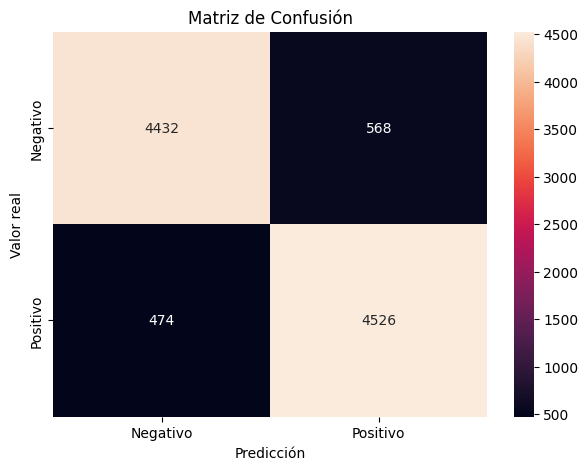

In [53]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Negativo",
        "Positivo"
    ],
    yticklabels=[
        "Negativo",
        "Positivo"
    ]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.title(
    "Matriz de Confusión"
)

plt.show()

In [54]:
coeficientes = modelo.coef_[0]

indices_ordenados = np.argsort(
    coeficientes
)

palabras_negativas = vocabulario[
    indices_ordenados[:20]
]

palabras_positivas = vocabulario[
    indices_ordenados[-20:]
]

print("Palabras asociadas a NEGATIVO:")
print(palabras_negativas)

print("\nPalabras asociadas a POSITIVO:")
print(palabras_positivas)



Palabras asociadas a NEGATIVO:
['worst' 'waste' 'bad' 'awful' 'boring' 'poor' 'terrible' 'nothing'
 'worse' 'poorly' 'horrible' 'dull' 'fails' 'disappointing'
 'unfortunately' 'disappointment' 'instead' 'stupid' 'annoying'
 'ridiculous']

Palabras asociadas a POSITIVO:
['fantastic' 'enjoyable' 'definitely' 'love' 'superb' 'well' 'highly'
 'brilliant' 'today' 'fun' 'enjoyed' 'hilarious' 'favorite' 'wonderful'
 'loved' 'amazing' 'best' 'perfect' 'excellent' 'great']


In [55]:
print(type(vectorizador))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


## aplicacion cuando ingresa una nueva reseña:

In [56]:
nueva_resena = [
    "This dataset from the MNIST collection provides a suitable foundation for practicing deep learning fundamentals with"
]

In [57]:
nueva_limpia = [
    limpiar_texto(texto)
    for texto in nueva_resena
]

In [58]:
nueva_tokens = [
    tokenizar(texto)
    for texto in nueva_limpia
]


In [59]:
nueva_sin_stopwords = [
    eliminar_stopwords(tokens)
    for tokens in nueva_tokens
]

In [60]:
nueva_lematizada = [
    aplicar_lemmatizacion(tokens)
    for tokens in nueva_sin_stopwords
]

In [61]:
nueva_procesada = [
    " ".join(tokens)
    for tokens in nueva_lematizada
]

In [62]:
#  REPRESENTACIÓN TF-IDF


nueva_tfidf = vectorizador.transform(
    nueva_procesada
)

print("Transformación TF-IDF realizada correctamente")
print("Forma:", nueva_tfidf.shape)

Transformación TF-IDF realizada correctamente
Forma: (1, 20000)


In [63]:
vectorizador.transform(nueva_procesada)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8 stored elements and shape (1, 20000)>

In [64]:
nueva_tfidf = vectorizador.transform(
    nueva_procesada
)

In [65]:
prediccion = modelo.predict(
    nueva_tfidf
)

print(prediccion)

[1]


In [66]:
probabilidades = modelo.predict_proba(
    nueva_tfidf
)

print(probabilidades)

[[0.31155369 0.68844631]]


In [67]:
prob_negativo = probabilidades[0][0]
prob_positivo = probabilidades[0][1]

print(f"Negativo: {prob_negativo:.2%}")
print(f"Positivo: {prob_positivo:.2%}")

Negativo: 31.16%
Positivo: 68.84%


In [68]:
if prob_positivo >= 0.60:
    resultado = "POSITIVO"

elif prob_negativo >= 0.60:
    resultado = "NEGATIVO"

else:
    resultado = "NEUTRO"

print(f"\nSentimiento: {resultado}")


Sentimiento: POSITIVO


In [69]:
print(type(vectorizador))
print(type(modelo))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
<class 'sklearn.linear_model._logistic.LogisticRegression'>


#  pytorch ####

In [70]:
# aca empieza funcion para predecir el sentimiento con pytorch

In [71]:
%pip install torch

In [72]:
import torch


In [73]:
%pip install torch


In [74]:
import torch
print(torch.__version__)

2.13.0+cu130


In [75]:
import numpy as np
vector = np.array(
    [1,2,3,4]
)

print(vector)

[1 2 3 4]


In [76]:
# en pytorch
import torch
tensor = torch.tensor(
    [1 ,2, 3,4]
)

print(tensor)
# un tensor es una estructura numerica que puede utilizarse para los calculos de deep learning

tensor([1, 2, 3, 4])


In [77]:
print(tensor.shape)

torch.Size([4])


In [78]:
# vamos crear vocalubario
#movie (1) - good(2) - great(3) - boring(4)

In [79]:
from collections import Counter
contador = Counter()

for texto in df["texto_procesado"]:
  palabras = texto.split()
  contador.update(palabras)

In [80]:
MAX_VOCAB_SIZE = 20000
# LIMITANDO EL VOCABULARIO PARA NO UTILIZAR DEMACIADAS PALABRAS

In [81]:
vocabulario = {
    "<PAD>":0,
    "<UNK>":1 # UNKNOW

}

for palabra, frecuencia in contador.most_common(
    MAX_VOCAB_SIZE -2
):
  vocabulario[palabra] = len(vocabulario)


In [82]:
def texto_a_indices(texto):
  palabras = texto.split()
  indices = []
  for palabra in palabras:
    indice = vocabulario.get(
        palabra,
        vocabulario["<UNK>"]
    )
    indices.append(indice)
  return indices

In [83]:
# probar
texto = "this movie was fantastic"

print(
    texto_a_indices(texto)
)

[1, 2, 1, 669]


In [84]:
# convertir a tensor
indices  = texto_a_indices (
    " this movie was fantastic"
)

tensor = torch.tensor(
    indices,
    dtype=torch.long
)

print(tensor)

tensor([  1,   2,   1, 669])


In [85]:
# vamos a comenzar con el entretanmiento

In [86]:
# dividir entrenamiento y prueba
X_train, X_test , y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [87]:
# limitar longitud
MAX_LENGTH = 200

In [88]:
#  CREAR FUNCION PADDING
def convertir_texto(texto):
  #convervirt el txto en indices
  indices = texto_a_indices(
      texto
  )
  #cortar la reseña
  indices = indices[:MAX_LENGTH]

  #calcular cuanto falta
  cantidad_padding=(
      MAX_LENGTH - len(indices)
  )

  # agrgamos 0
  indices = indices + (
      [vocabulario["<PAD>"]]
      * cantidad_padding
  )

  return indices

In [89]:
# vamos a probar
ejemplo = convertir_texto("this movie was fantastic favorite")
print(ejemplo)
print(len(ejemplo))

[1, 2, 1, 669, 347, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
200


In [90]:
#Convertir dataset de entrenamiento
X_train_indices = [
   convertir_texto(texto)
   for texto in X_train
]

X_test_indices = [
   convertir_texto(texto)
   for texto in X_test
]
#Convertir a Tensor
X_train_tensor = torch.tensor(
   X_train_indices,
   dtype=torch.long

)

X_test_tensor = torch.tensor(
   X_test_indices,
   dtype=torch.long

)

y_train_tensor = torch.tensor(
   y_train.values,
   dtype=torch.float32

)

y_test_tensor = torch.tensor(
   y_test.values,
   dtype=torch.float32

)

In [91]:
#Revisar dimensiones
print(
   "X_train:",
   X_train_tensor.shape
)

print(
   "X_test:",
   X_test_tensor.shape
)

print(
   "y_train:",
   y_train_tensor.shape
)

print(
   "y_test:",
   y_test_tensor.shape
)

X_train: torch.Size([40000, 200])
X_test: torch.Size([10000, 200])
y_train: torch.Size([40000])
y_test: torch.Size([10000])


In [93]:
#Crear Dataset de PyTorch
#PyTorch trabaja normalmente con Dataset y DataLoader.
from torch.utils.data import Dataset, DataLoader
class IMDBDataset(Dataset):

   def __init__(

       self,
       textos,
       etiquetas

   ):



       self.textos = textos
       self.etiquetas = etiquetas


   def __len__(self):

       return len(
           self.textos
       )
   def __getitem__(self, indice):
        return (
           self.textos[indice],
           self.etiquetas[indice]

       )


In [94]:
#Crear datasets
train_dataset = IMDBDataset(
   X_train_tensor,
   y_train_tensor

)

test_dataset = IMDBDataset(
   X_test_tensor,
   y_test_tensor

)


In [95]:
#DataLoader
train_loader = DataLoader(
   train_dataset,
   batch_size=64,
   shuffle=True
)

test_loader = DataLoader(
   test_dataset,
   batch_size=64,
   shuffle=False

)

In [96]:
#Crear la red neuronal
import torch.nn as nn
class ModeloSentimiento(nn.Module):
   def __init__(
       self,
       vocab_size,
       embedding_dim=100
   ):

       super().__init__()

       # EMBEDDING
       self.embedding = nn.Embedding(
           vocab_size,
           embedding_dim,
           padding_idx=0
       )

       # CAPA LINEAL
       self.fc = nn.Linear(
           embedding_dim,
           1
       )


In [101]:
# Completar forward()
class ModeloSentimiento(nn.Module):
   def __init__(
       self,
       vocab_size,
       embedding_dim=100

   ):


       super().__init__()

       self.embedding = nn.Embedding(
           vocab_size,
           embedding_dim,
           padding_idx=0

       )

       self.fc = nn.Linear(
           embedding_dim,
           1

       )


   def forward(self, x):
       # Convertir índices en embeddings
       x = self.embedding(x)
       # Promedio de embeddings
       x = x.mean(
           dim=1
       )

       #Capa final
       x = self.fc(x)
       return x.squeeze(1)

In [98]:
#Crear modelo
modelo_torch = ModeloSentimiento(
   vocab_size=len(vocabulario),

   embedding_dim=100

)
print(modelo_torch)

ModeloSentimiento(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)


In [99]:
#Función de pérdida
criterio = nn.BCEWithLogitsLoss()
#%pip install --upgrade torch torchvision torchaudio
#Optimizador

optimizador = torch.optim.Adam(

   modelo_torch.parameters(),

   lr=0.001

)
print(optimizador)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [104]:
modelo_torch.eval()



correctos = 0

total = 0





with torch.no_grad():



   for textos, etiquetas in test_loader:



       salidas = modelo_torch(

           textos

       )



       probabilidades = torch.sigmoid( #

           salidas

       )



       predicciones = (

           probabilidades >= 0.5

       ).float()





       correctos += (

           predicciones == etiquetas

       ).sum().item()





       total += etiquetas.size(0)


accuracy_torch = (

   correctos / total

)

print(

   f"Accuracy PyTorch: "

   f"{accuracy_torch:.4f}"
)

Accuracy PyTorch: 0.5003
